# VẤN ĐỀ: TẠI SAO ĐƠN THÀNG THÁNG 12/2011 GIẢM ĐỘT BIẾN

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import math
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Các công cụ tiền xử lý dữ liệu và thống kê
from scipy.stats import skew, norm, probplot, boxcox
from sklearn.preprocessing import StandardScaler, Normalizer

# Hồi quy
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Mô hình phân cụm và đánh giá (K-Means & Silhouette)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# Công cụ trực quan hóa tương tác (Plotly)
import plotly.graph_objs as go

# I. Hiểu vấn đề kinh doanh
## 1. Xác nhận vấn đề (confirm the proplem)

*   Số lượng đơn hàng tháng 12/2011 là bao nhiêu?, So với 11/2011 và 12/2010?
*   Dataset có dầy đủ cho toàn bộ 12/2011 không?(1-31)
*   Thổng doah thu tháng 12/2011 có giảm như số đơn hàng không?

## 2. Phân tích theo thời gian ( time analysis)

*   So sánh số đơn hàng các tháng trong 2011?
*   So sánh theo từng tuần trong tháng 12? tuần nào có đơn hàng tuần nào ko ?
*   Tháng 12/2010 có cùng hiện tượng không?

## 3. Phân tích theo thi trừơng (market analysis)

  * Thị trường nào (country) đóng góp nhiều nhất vào doanh số? Thị trường nào giảm mạnh nhất?

## 4. Phân tích theo sản phẩm (produce analysis)

*   Top 10 sản phẩm bán chạy nhất - có sản phẩm nào biến mất khỏi danh sách không?
*   Có sản phẩm nào bị trả lại hoặc hủy đơn nhiều bất thường tháng 12 không?

## 5. Phân tích theo khách hàng (customer analysis)

*   Số lượng khách hàng trong tháng 12/2011? so vs các tháng
*   Top khách hàng (high-value) tháng 11 có tiếp tục mua ở tháng 12 không?
*   tỉ lệ khách hàng mới vs khách hàng cũ tháng 12 thay đổi thê nào?

## 6. Chất lượng dữ liệu  (Data quanlity)

*  Tỉ lệ null mã KH tháng 12 có khác biệt so với các tháng khác không?
*   Ngày giao dịch cuối cùng?






  






# II. Hiểu dữ liệu

In [ ]:
#đọc dữ liệu
df = pd.read_csv('/content/drive/MyDrive/NoteDA/r/301_ASM1/online_retail_new.csv', sep=';')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01/12/2009 7:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01/12/2009 7:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01/12/2009 7:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01/12/2009 7:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01/12/2009 7:45,1.25,13085.0,United Kingdom


In [ ]:
#Hình đáng
print("\n1. dòng ,côt: ",df.shape)
print("\n2. tên cột",df.columns)
print("\n3. Tỉ lệ dl thiếu")
missing_summary= pd.DataFrame({
    "total_mising": df.isnull().sum(),
    "mising_ratio (%)": round((df.isnull().sum()/df.shape[0])*100,2),
    "data_type": df.dtypes
    })
print(missing_summary)

#4. phân tích cấu trúc dữ liêu
print("\n4. cấu trúc dữ liệu")
number_col = df.select_dtypes(include=np.number).columns.tolist()
categorical_col = df.select_dtypes(include='object').columns.tolist()
datetimes_col = df.select_dtypes(include='datetime64').columns.tolist()
print("number_col: ",number_col,"\ncategorical_col: ",categorical_col,"\ndatetimes_col: ",datetimes_col)

#5 thống kê mô tả
print("\n5. thống kê mô tả")
print("\n5.1. Thống kê cột số")
if number_col:
  print(df[number_col].describe().T.round(2))

print("\n5.2. Thống kê cột phân loại")
if categorical_col:
  print(df[categorical_col].describe().T.round())
print("\n5.3. Thống kê cột thời gian")
if datetimes_col:
  print(df[datetimes_col].describe())
  print(' \n Thời gian bắt đầu: ', df['InvoiceDate'].min())
  print('Thời gian kết thúc: ', df['InvoiceDate'].max())




1. dòng ,côt:  (1048575, 8)

2. tên cột Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

3. Tỉ lệ dl thiếu
             total_mising  mising_ratio (%) data_type
Invoice                 0              0.00    object
StockCode               0              0.00    object
Description          4372              0.42    object
Quantity                0              0.00     int64
InvoiceDate             0              0.00    object
Price                   0              0.00   float64
Customer ID        236682             22.57   float64
Country                 0              0.00    object

4. cấu trúc dữ liệu
number_col:  ['Quantity', 'Price', 'Customer ID'] 
categorical_col:  ['Invoice', 'StockCode', 'Description', 'InvoiceDate', 'Country'] 
datetimes_col:  []

5. thống kê mô tả

5.1. Thống kê cột số
                 count      mean      std       min       25%      50%  \
Quantity     1048575.0   

- Tồn tại Quantity<0 , price<0
- Định dạng cột thời gian

- tỉ lệ cột CustomerID trống ~ 22.6% . quyết định xóa dòng dl trống

# III. Làm Sạch dữ liệu

Kiểm tra dữ liệu

* có bao nhiêu  Quantity <0 or  Price < 0
* Tất cả các giao dịch với quantity <0 thì hóa đơn kết thúc bằng kí tự gì?

 Yêu cầu dữ liệu:

*   "Quantity">= 0
*   "Price" >= 0
*   Custommer ID not null



In [ ]:
# vì cọt ngày dịnh dạng object--> chuyển sang datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d/%m/%Y %H:%M')

print('Số giao dịch có "Quantity" <0 hoặc "Price" <0 là:', len(df[(df['Quantity']<0) |(df['Price']<0) ]))
print('tất cả các gioa dịch có "Quantity" <0 thì bắt đầu bằng các kí tự: ',  df[df['Quantity']<0]['Invoice'].str[0].unique() )
# Loại bỏ Quantity hoặc UnitPrice âm/zero
df_cs = df.dropna(subset=['Customer ID'])
df_cs = df_cs[(df_cs['Quantity']>0) & (df_cs['Price']>0)]
df_cs.head()
# Tạo cột Revenue và thời gian


Số giao dịch có "Quantity" <0 hoặc "Price" <0 là: 22702
tất cả các gioa dịch có "Quantity" <0 thì bắt đầu bằng các kí tự:  ['C' '4' '5']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# 1,2,3 Hình đáng
print("\n1. dòng ,côt: ",df_cs.shape)
print(f"      Chiếm {round(df_cs.shape[0]/len(df)*100,2)} % so với dữ liệu gốc")
print("\n2. tên cột",df_cs.columns)
print("\n3. Tỉ lệ dl thiếu")
missing_summary= pd.DataFrame({
    "total_mising": df_cs.isnull().sum(),
    "mising_ratio (%)": (df_cs.isnull().sum()/df_cs.shape[0])*100,
    "data_type": df_cs.dtypes
    })
print(missing_summary)

df_cs['InvoiceDate'] = pd.to_datetime(df_cs['InvoiceDate'], format='%d/%m/%Y %H:%M')

#4. phân tích cấu trúc dữ liêu
print("\n4. cấu trúc dữ liệu")
number_col = df_cs.select_dtypes(include=np.number).columns.tolist()
categorical_col = df_cs.select_dtypes(include='object').columns.tolist()
datetimes_col = df_cs.select_dtypes(include='datetime64').columns.tolist()
print("number_col: ",number_col,"\ncategorical_col: ",categorical_col,"\ndatetimes_col: ",datetimes_col)

#5 thống kê mô tả
print("\n5. thống kê mô tả")
print("\n5.1. Thống kê cột số")
print(df_cs[number_col].describe().T.round(2))
print("\n   Phân tích outlier")
for col in number_col:
  Q1 = df_cs[col].quantile(0.25)
  Q3 = df_cs[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df_cs[(df_cs[col] < lower_bound) | (df_cs[col] > upper_bound)]
  outlier_percentage = (len(outliers) / len(df_cs)) * 100
  print(f'Outliers percentage of "{col}" columns: ')
  print(round(outlier_percentage,2), '%')

print("\n5.2. Thống kê cột phân loại")
print(df_cs[categorical_col].describe().T.round())
print("\n5.3. Thống kê cột thời gian")
print(df_cs[datetimes_col].describe())

# Dũ liệu trùng lặp
print('\n6. dữ liệu trùng lặp')
duplicated_count = df_cs.duplicated().sum()
if duplicated_count > 0:
    print(f'Tỉ lệ trùng lặp {(duplicated_count/len(df))*100} %')
else:
    print('Không có dòng dữ liệu trùng lặp.')
duplicates = df_cs[df_cs.duplicated(keep=False)]
print(duplicates)
# #xóa các dòng trùng lặp hoàn toàn, giữ lại dòng đầu tiên (keep='first')
df_cs=df_cs.drop_duplicates(keep='first')
#


1. dòng ,côt:  (793309, 8)
      Chiếm 75.66 % so với dữ liệu gốc

2. tên cột Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

3. Tỉ lệ dl thiếu
             total_mising  mising_ratio (%)       data_type
Invoice                 0               0.0          object
StockCode               0               0.0          object
Description             0               0.0          object
Quantity                0               0.0           int64
InvoiceDate             0               0.0  datetime64[ns]
Price                   0               0.0         float64
Customer ID             0               0.0         float64
Country                 0               0.0          object

4. cấu trúc dữ liệu
number_col:  ['Quantity', 'Price', 'Customer ID'] 
categorical_col:  ['Invoice', 'StockCode', 'Description', 'Country'] 
datetimes_col:  ['InvoiceDate']

5. thống kê mô tả

5.1. Thống kê cột số
         

#IV. Modeling / Analysis — Phân tích chuyên sâu


In [ ]:
# Tạo cột Revenue và thời gian
df_cs["Revenue"] = df_cs["Quantity"] * df_cs["Price"]
df_cs["Month"] = df_cs["InvoiceDate"].dt.strftime("'%y-%m")#.to_period('M')
df_cs["Year"]= df_cs["InvoiceDate"].dt.year
df_cs["MonthNum"] = df_cs["InvoiceDate"].dt.month
df_cs["Day"] = df_cs["InvoiceDate"].dt.day
df_cs["DayOfWeek"] = df_cs["InvoiceDate"].dt.day_name()
df_cs["WeekNum"] = df_cs["InvoiceDate"].dt.strftime("%V")
df_cs["Week"] = df_cs["InvoiceDate"].dt.isocalendar().week
df_cs["Quarter"] = df_cs["InvoiceDate"].dt.to_period('Q')
df_cs["QuarterNum"] = df_cs["InvoiceDate"].dt.quarter
df_cs["Hour"] = df_cs["InvoiceDate"].dt.hour
df_cs["Minute"] = df_cs["InvoiceDate"].dt.minute
df_cs["Second"] = df_cs["InvoiceDate"].dt.second
df_cs["Day"] = df_cs["InvoiceDate"].dt.day
df_cs.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,...,MonthNum,Day,DayOfWeek,WeekNum,Week,Quarter,QuarterNum,Hour,Minute,Second
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,'09-12,...,12,1,Tuesday,49,49,2009Q4,4,7,45,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,'09-12,...,12,1,Tuesday,49,49,2009Q4,4,7,45,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,'09-12,...,12,1,Tuesday,49,49,2009Q4,4,7,45,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,'09-12,...,12,1,Tuesday,49,49,2009Q4,4,7,45,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,'09-12,...,12,1,Tuesday,49,49,2009Q4,4,7,45,0


In [ ]:
# đếm số ngày có dữ liêij
#Data_time=pd.DataFrame(df_cs[df_cs["Year"]==2011].groupby("Month")["Invoice"].count())
#Data_time["SoNgay"] = df_cs[df_cs["Year"]==2011].groupby("Month")["Day"].nunique().values
#Data_time["BinhQuan"]=Data_time["Invoice"]/Data_time["SoNgay"]
#Data_time

## 1. phân tích theo thời gian


*  thống kê số đơn hàng và doanh thu và bình quân số đơn hàng các tháng trong năm 2011.
*  thống kê số đơn hàng và doanh thu các tháng trong bộ dữ liệu



In [ ]:
# # thống kê số đơn hàng, doanh thu , số khách hàng các tháng trong năm 2011
Data_2011=pd.DataFrame(df_cs[df_cs["Year"]==2011].groupby("Month")["Invoice"].count())
Data_2011["SoNgay"] = (df_cs[df_cs["Year"]==2011].groupby("Month")["InvoiceDate"].max()-df_cs[df_cs["Year"]==2011].groupby("Month")["InvoiceDate"].min()).dt.days
Data_2011["BinhQuan"]=Data_2011["Invoice"]/Data_2011["SoNgay"]
Data_2011["revenue"]=df_cs[df_cs["Year"]==2011].groupby("Month")["Revenue"].sum()
print(Data_2011.describe())
Data_2011

            Invoice     SoNgay     BinhQuan       revenue
count     12.000000  12.000000    12.000000  1.200000e+01
mean   29580.583333  26.666667  1146.881152  6.582417e+05
std    14956.071509   7.547827   462.979670  2.837607e+05
min     4971.000000   3.000000   729.851852  9.930512e+04
25%    22071.750000  27.000000   872.212963  5.431696e+05
50%    26830.000000  29.000000   912.074713  6.215070e+05
75%    30972.000000  30.000000  1440.172414  7.456889e+05
max    63168.000000  30.000000  2178.206897  1.156206e+06


,Invoice,SoNgay,BinhQuan,revenue
Month,,,,
'11-01,20988,27,777.333333,568101.310
'11-02,19706,27,729.851852,446084.920
'11-03,26870,30,895.666667,594081.760
'11-04,22433,27,830.851852,468374.331
'11-05,28073,30,935.766667,677355.150
'11-06,26926,29,928.482759,660046.050
'11-07,26580,30,886.000000,598962.901
'11-08,26790,30,893.000000,644051.040
'11-09,39669,29,1367.896552,950690.202


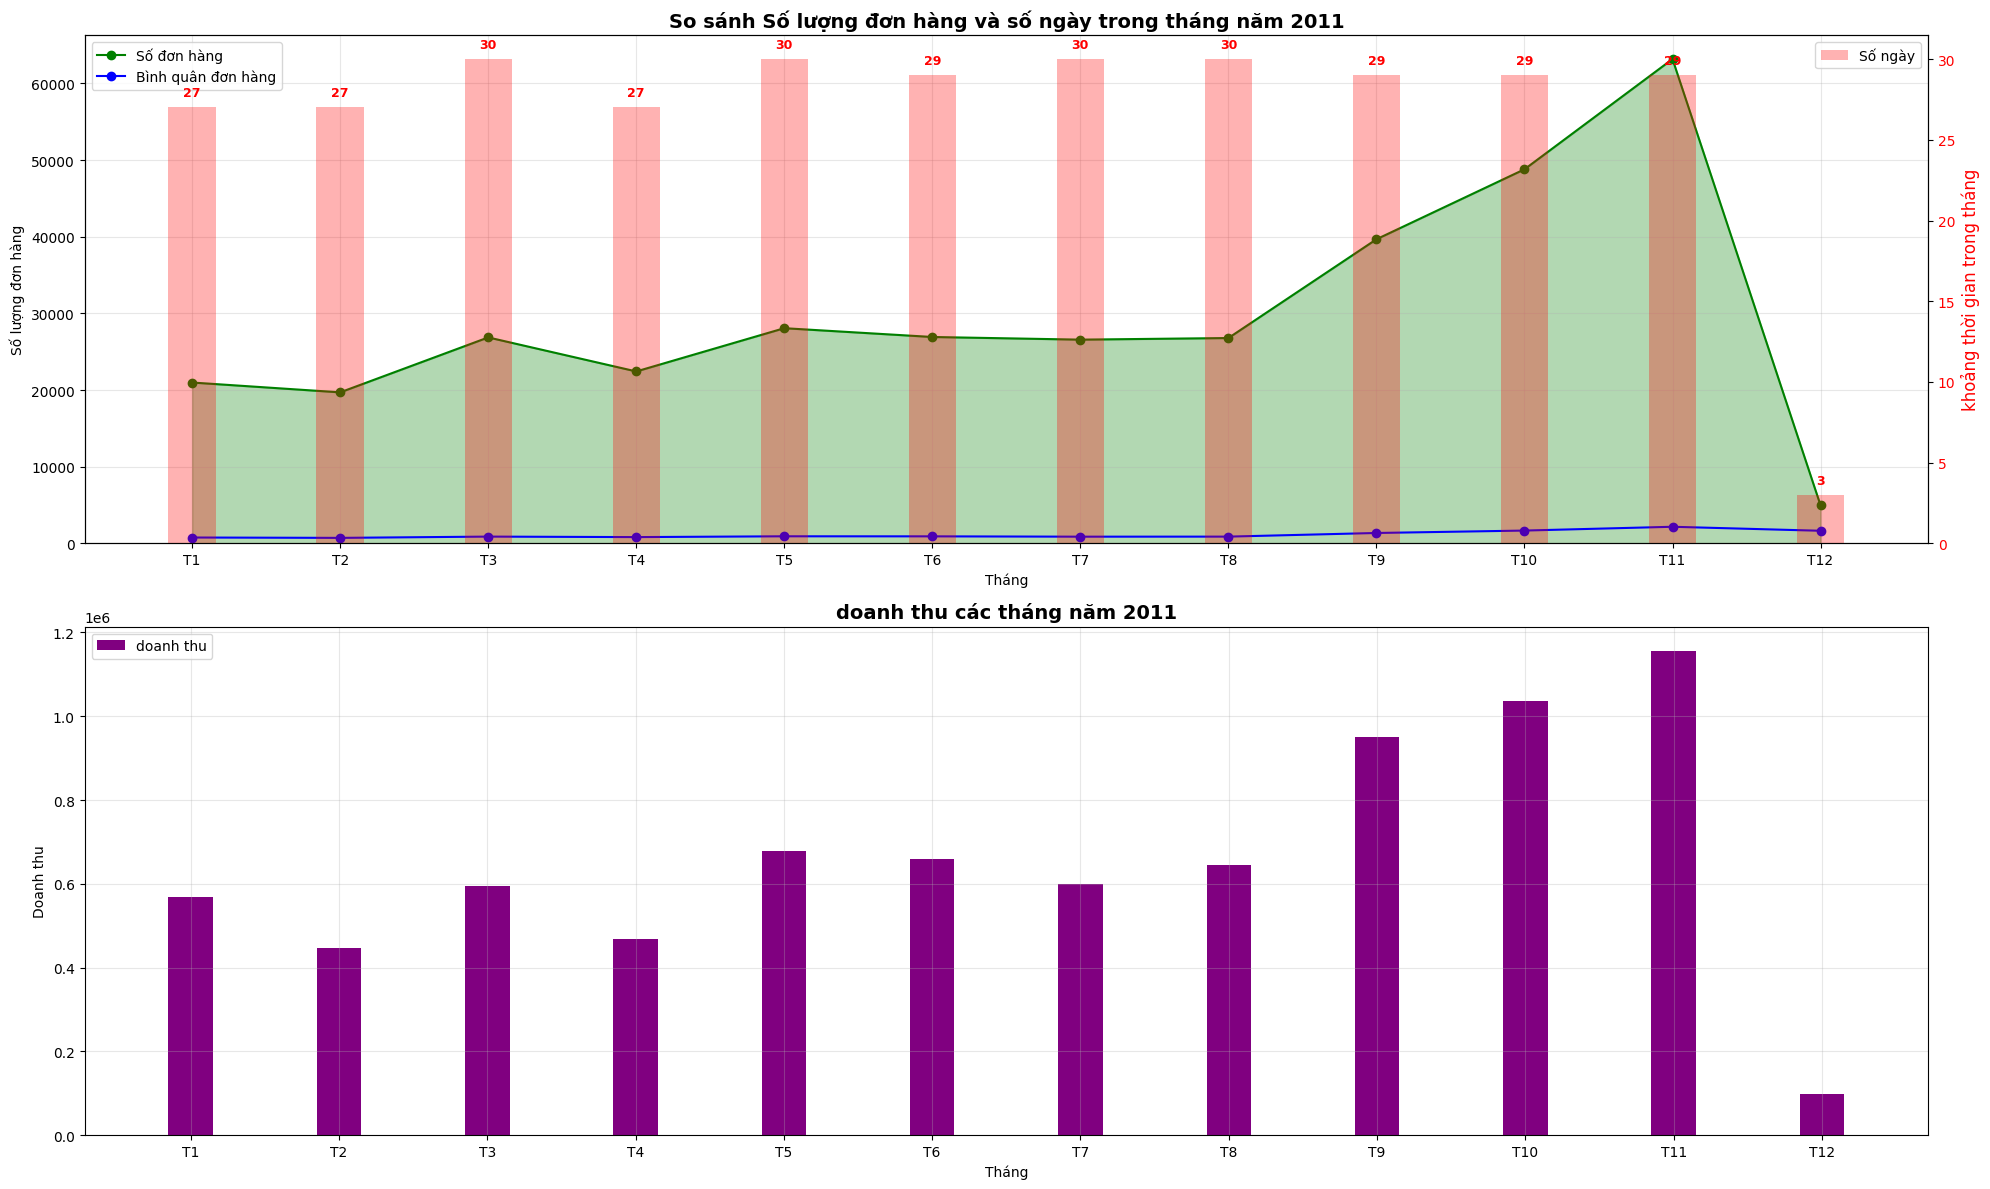

In [ ]:
# Thêm ngoặc vuông [] vào trong hàm groupby
x=['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12']
fig,[ax,ax_] = plt.subplots(2,1,figsize=(20, 12))
ax.plot(Data_2011.index.astype(str), Data_2011.Invoice, marker='o', linestyle='-', color='g',label='Số đơn hàng')
ax.plot(Data_2011.index.astype(str), Data_2011.BinhQuan, marker='o', linestyle='-', color='b',label='Bình quân đơn hàng')
ax.fill_between(Data_2011.index.astype(str), Data_2011.Invoice, alpha=0.3, color='green')
ax.set_xticks(range(len(x)))
ax.set_xticklabels(x)
ax.set_xlabel('Tháng')
ax.set_ylabel('Số lượng đơn hàng')
ax.set_ylim(ymin=0)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
#------------------------------------------------------------------------------------
# KHỞI TẠO HỆ TRỤC Y THỨ HAI (ax2 - bên phải) DÙNG CHUNG TRỤC X

ax2 = ax.twinx()
ax2.bar(Data_2011.index.astype(str), Data_2011['SoNgay'], color='red', label='Số ngày',width=0.32,alpha=0.3)

# Cấu hình cho trục Y thứ hai (Bên phải)
ax2.set_ylabel('khoảng thời gian trong tháng', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red') # Đổi màu các con số trên trục Y2 thành màu đỏ
for i in range(len(Data_2011)):
    gia_tri_y = Data_2011['SoNgay'].values[i]
    ax2.annotate(
        text=f"{gia_tri_y}",          # Nội dung ghi chú (dấu :, để định dạng kiểu 60,000)
        xy=(i, gia_tri_y),     # Tọa độ chính xác của điểm dữ liệu (X, Y)
        xytext=(0, 8),                        # Khoảng cách dịch chuyển chữ (ngang 0, dọc lên trên 8 pixels)
        textcoords="offset points",     # Xác định kiểu dịch chuyển là theo pixel từ điểm gốc
        ha='center',                    # Căn lề chữ nằm CHÍNH GIỮA điểm chấm tròn (horizontal alignment)
        fontsize=9,                     # Cỡ chữ của ghi chú
        fontweight='bold',              # In đậm chữ cho dễ đọc
        color='red'               # Màu sắc của chữ ghi chú
    )
ax.set_title('So sánh Số lượng đơn hàng và số ngày trong tháng năm 2011', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
# ---------------------------------------------------------------------------------------------------------
#x=['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12']

ax_.bar(Data_2011.index.astype(str), Data_2011.revenue, color='purple',label='doanh thu',width=0.3)
#ax.plot(Data_time.index.astype(str), Data_time.BinhQuan, marker='o', linestyle='-', color='b',label='Bình quân đơn hàng')
#ax.fill_between(Data_time.index.astype(str), Data_time.Invoice, alpha=0.3, color='green')
ax_.set_xticks(range(len(x)))
ax_.set_xticklabels(x)
ax_.set_xlabel('Tháng')
ax_.set_ylabel('Doanh thu')
ax_.set_ylim(ymin=0)
ax_.grid(True, alpha=0.3)
ax_.legend(loc='upper left')
ax_.set_title('doanh thu các tháng năm 2011', fontsize=14, fontweight='bold')

for i in range(len(Data_2011)):
    gia_tri_y = Data_2011['revenue'].values[i]
    ax2.annotate(
        text=f"{gia_tri_y}",          # Nội dung ghi chú (dấu :, để định dạng kiểu 60,000)
        xy=(i, gia_tri_y),     # Tọa độ chính xác của điểm dữ liệu (X, Y)
        xytext=(0, 8),                        # Khoảng cách dịch chuyển chữ (ngang 0, dọc lên trên 8 pixels)
        textcoords="offset points",     # Xác định kiểu dịch chuyển là theo pixel từ điểm gốc
        ha='center',                    # Căn lề chữ nằm CHÍNH GIỮA điểm chấm tròn (horizontal alignment)
        fontsize=9,                     # Cỡ chữ của ghi chú
        fontweight='bold',              # In đậm chữ cho dễ đọc
        color='red'               # Màu sắc của chữ ghi chú
    )

# 3. XỬ LÝ HIỂN THỊ TIÊU ĐỀ

plt.tight_layout()
plt.show()


- biểu đồ thể hiện số đơn hàng tháng 12/2011 thấp hơn rất nhiều so với các tháng trong năm 2011. tuy nhiên điều này không có nghĩa là có vấn đề kinh doanh vì số ngày dữ liệu chỉ có 3 ngày < 75% số ngày tối thiểu trong 1 tháng
- Khoảng thời gian dữ liệu: 2009-12-01 đến 2011-12-04
- bình quân số đơn hàng ổn định, Số đơn hàng  tương đương với số lượng ngày

In [ ]:
# thống kê số đơn hàng, doanh thu , số khách hàng các tháng trong dữ liệu
monthly = df_cs.groupby('Month').agg(
    orders=('Invoice', 'nunique'),
    revenue=('Revenue', 'sum'),
    customers=('Customer ID', 'nunique')
    ).reset_index()

print(monthly)

     Month  orders      revenue  customers
0   '09-12    1512   683504.010        955
1   '10-01    1011   555802.672        720
2   '10-02    1104   504558.956        772
3   '10-03    1524   696978.471       1057
4   '10-04    1329   591982.002        942
5   '10-05    1377   597833.380        966
6   '10-06    1497   636371.130       1041
7   '10-07    1381   589736.170        928
8   '10-08    1293   602224.600        911
9   '10-09    1689   829013.951       1145
10  '10-10    2133  1033112.010       1497
11  '10-11    2587  1166460.022       1607
12  '10-12    1400   570422.730        885
13  '11-01     987   568101.310        741
14  '11-02     997   446084.920        758
15  '11-03    1321   594081.760        974
16  '11-04    1149   468374.331        856
17  '11-05    1555   677355.150       1056
18  '11-06    1393   660046.050        991
19  '11-07    1331   598962.901        949
20  '11-08    1280   644051.040        935
21  '11-09    1755   950690.202       1266
22  '11-10 

In [ ]:
# thống kê số đơn hàng, doanh thu , số khách hàng các tháng trong dữ liệu
monthly["orders_log"]=monthly['orders'].apply(lambda x: np.log(x))
monthly["revenue_log"]=monthly['revenue'].apply(lambda x: np.log(x))
monthly["customers_log"]=monthly['customers'].apply(lambda x: np.log(x))
Scale = StandardScaler()
monthly[["orders_log","revenue_log","customers_log"]]=Scale.fit_transform(monthly[["orders_log","revenue_log","customers_log"]])
monthly

,Month,orders,revenue,customers,orders_log,revenue_log,customers_log
0,'09-12,1512,683504.010,955,0.253741,0.190369,0.000044
1,'10-01,1011,555802.672,720,-0.707691,-0.261655,-0.774000
2,'10-02,1104,504558.956,772,-0.497486,-0.473066,-0.582905
3,'10-03,1524,696978.471,1057,0.272624,0.233037,0.278133
4,'10-04,1329,591982.002,942,-0.054416,-0.123825,-0.037515
5,'10-05,1377,597833.380,966,0.030336,-0.102327,0.031428
6,'10-06,1497,636371.130,1041,0.229925,0.034207,0.236334
7,'10-07,1381,589736.170,928,0.037265,-0.132132,-0.078548
8,'10-08,1293,602224.600,911,-0.120013,-0.086332,-0.129214
9,'10-09,1689,829013.951,1145,0.518177,0.612201,0.497280


In [ ]:
# mô tả dữ liệu
monthly.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
orders,25.0,1458.28,498.16,266.00,1280.00,1381.00,1555.00,2657.00
revenue,25.0,678276.04,238395.30,99305.12,570422.73,602224.60,696978.47,1166460.02
customers,25.0,1008.44,302.46,231.00,885.00,955.00,1057.00,1664.00
orders_log,25.0,-0.00,1.02,-3.90,-0.14,0.04,0.32,1.60
revenue_log,25.0,0.00,1.02,-4.03,-0.20,-0.09,0.23,1.36
customers_log,25.0,-0.00,1.02,-3.89,-0.21,0.00,0.28,1.52


/tmp/ipykernel_13631/1668417477.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(monthly.Month, fontsize=8)
/tmp/ipykernel_13631/1668417477.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(monthly.Month, fontsize=8)
/tmp/ipykernel_13631/1668417477.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  c.set_xticklabels(monthly.Month, fontsize=8)
/tmp/ipykernel_13631/1668417477.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  d.set_xticklabels(monthly.Month, fontsize=8)


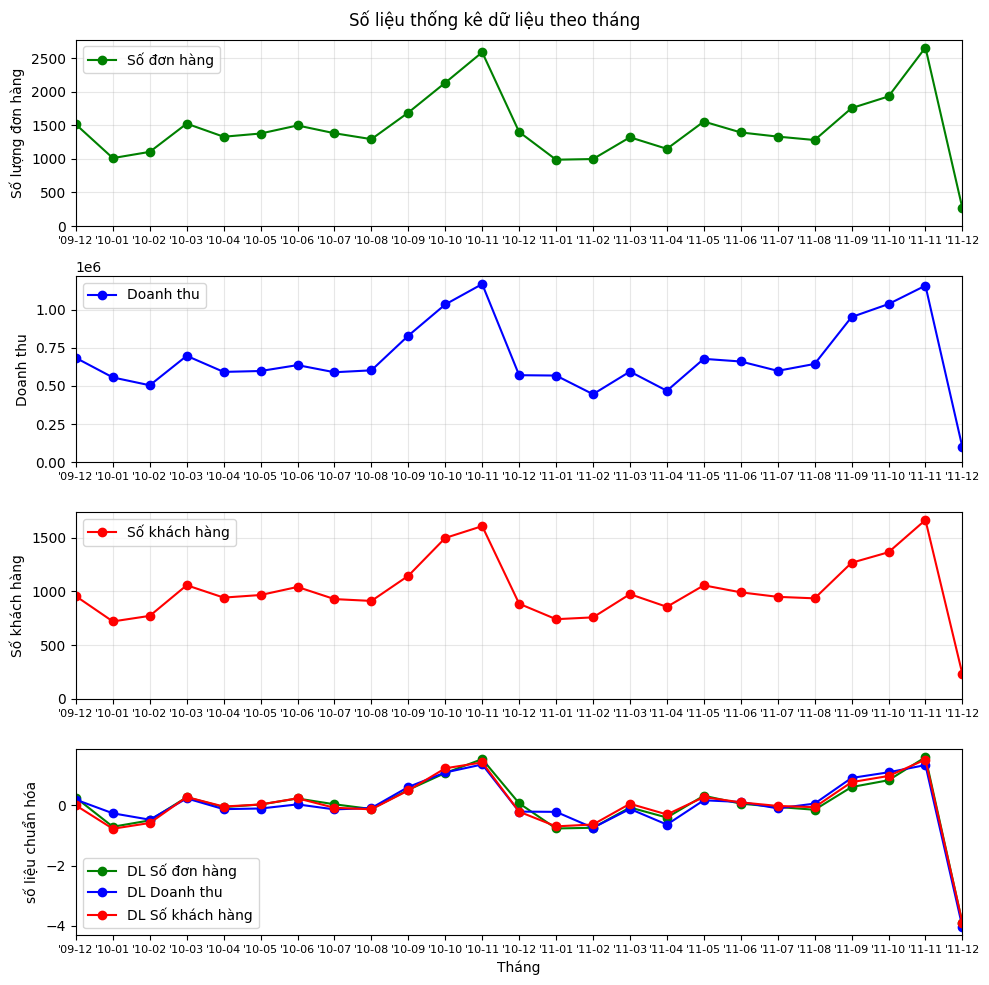

In [ ]:
# visualization số iệu các tháng năm 2011
fig,(a,b,c,d) = plt.subplots(4,1,figsize=(10, 10))
#fig,((a,b),(c,d)) = plt.subplots(2,2,figsize=(15, 9))
a.plot(monthly.index.astype(str), monthly.orders, marker='o', linestyle='-', color='g',label='Số đơn hàng')
b.plot(monthly.index.astype(str), monthly.revenue, marker='o', linestyle='-', color='b',label='Doanh thu')
c.plot(monthly.index.astype(str), monthly.customers, marker='o', linestyle='-', color='r',label='Số khách hàng')
a.set_ylabel('Số lượng đơn hàng')
a.set_xlim(xmin=0,xmax=24)
a.set_ylim(ymin=0)
a.grid(True, alpha=0.3)
a.set_xticklabels(monthly.Month, fontsize=8)
a.legend(loc='upper left')
b.set_ylabel('Doanh thu')
b.set_xlim(xmin=0,xmax=24)
b.set_ylim(ymin=0)
b.grid(True, alpha=0.3)
b.set_xticklabels(monthly.Month, fontsize=8)
b.legend(loc='upper left')
c.set_ylabel('Số khách hàng')
c.set_xlim(xmin=0,xmax=24)
c.set_ylim(ymin=0)
c.grid(True, alpha=0.3)
c.set_xticklabels(monthly.Month, fontsize=8)
c.legend(loc='upper left')
fig.suptitle("Số liệu thống kê dữ liệu theo tháng")
d.plot(monthly.index.astype(str), monthly.orders_log, marker='o', linestyle='-', color='g',label='DL Số đơn hàng')
d.plot(monthly.index.astype(str), monthly.revenue_log, marker='o', linestyle='-', color='b',label='DL Doanh thu')
d.plot(monthly.index.astype(str), monthly.customers_log, marker='o', linestyle='-', color='r',label='DL Số khách hàng')
d.set_xlim(xmin=0,xmax=24)
d.set_xticklabels(monthly.Month, fontsize=8)
d.legend(loc='lower left')
d.set_ylabel('số liệu chuẩn hóa')
d.set_xlabel('Tháng')
plt.tight_layout()
plt.show()


* Số đơn hàng, doanh thu và số khách hàng tỷ lệ với nhau qua các tháng trong các năm
*   ba tháng cuối năm 9,10,11 có doanh số đạt đỉnh trong năm
*tháng 12 các năm 2009, 2010  ố đơn hàng, doanh thu và số khách hàng đều nằm trong khoảng trung bình so với các tháng
* doanh số thấp nhất rơi vào các tháng 1,2 các năm 2010,2011 nhưng vẫn nằm trong khoảng trung bình

## 2. phân tích theo country

In [ ]:
dec_2011 = df_cs[df_cs['Month'] == "'11-12"]
nov_2011 = df_cs[df_cs['Month'] == "'11-11"]
dec_country = dec_2011.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
nov_country = nov_2011.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
print("Dec Top 5:", dec_country.head(),"\n")
print("Nov Top 5:", nov_country.head())

Dec Top 5: Country
United Kingdom    92104.69
France             2510.64
Portugal           1436.93
Finland            1232.76
Germany             762.87
Name: Revenue, dtype: float64 

Nov Top 5: Country
United Kingdom    975251.39
France             31274.75
EIRE               29448.41
Germany            27967.68
Netherlands        25874.01
Name: Revenue, dtype: float64


## 3. phân tích theo khách hàng

In [ ]:
# Top 20 khách hàng tháng 11 — còn mua tháng 12?
top_nov = nov_2011.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False).head(20)
dec_customers = set(dec_2011['Customer ID'].dropna().unique())
top_nov_ids = set(top_nov.index)
missing_vip = top_nov_ids - dec_customers
print(f"VIP tháng 11 không mua tháng 12: {len(missing_vip)} khách")
print("Doanh thu bị mất:", top_nov[top_nov.index.isin(missing_vip)].sum())

VIP tháng 11 không mua tháng 12: 14 khách
Doanh thu bị mất: 172484.83


## kết luận


* Nguyên nhân chính (Primary): Dataset Online Retail UCI chỉ có dữ liệu đến ngày 09/12/2011. Tháng 12 chỉ có 9/31 ngày (~29% tháng), do đó số đơn hàng tự nhiên thấp hơn ~70% so với các tháng đầy đủ. Đây KHÔNG phải sụt giảm thực sự của business.
*   Mục danh sách



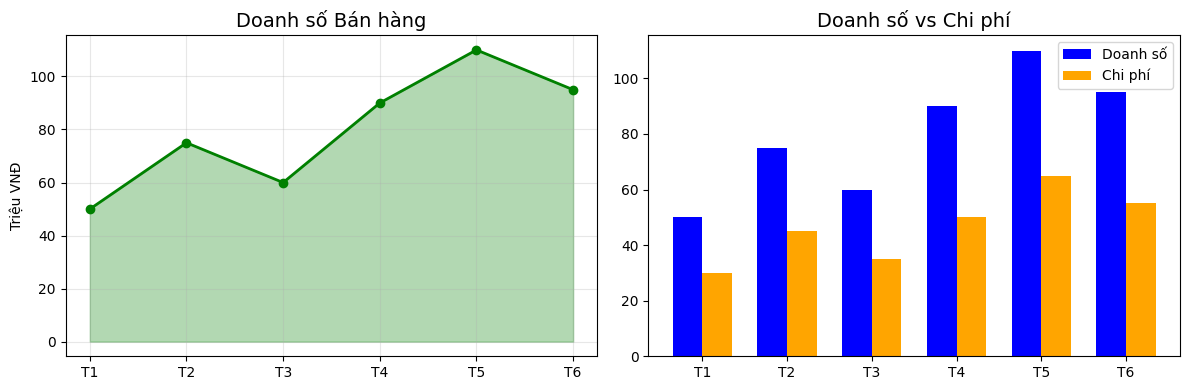

In [ ]:
#không thuộc bài toán trên

import matplotlib.pyplot as plt
import numpy as np


# Tạo dữ liệu
tháng = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6']
doanh_số = [50, 75, 60, 90, 110, 95]
chi_phí = [30, 45, 35, 50, 65, 55]


# Tạo hình với 2 biểu đồ con
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


# Biểu đồ 1: Doanh số theo tháng
ax1.plot(tháng, doanh_số, marker='o', linewidth=2, color='green')
ax1.fill_between(range(len(tháng)), doanh_số, alpha=0.3, color='green')
ax1.set_title('Doanh số Bán hàng', fontsize=14)
ax1.set_ylabel('Triệu VNĐ')
ax1.grid(True, alpha=0.3)


# Biểu đồ 2: So sánh Doanh số vs Chi phí
x = np.arange(len(tháng))
width = 0.35
ax2.bar(x - width/2, doanh_số, width, label='Doanh số', color='blue')
ax2.bar(x + width/2, chi_phí, width, label='Chi phí', color='orange')
ax2.set_title('Doanh số vs Chi phí', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(tháng)
ax2.legend()


plt.tight_layout()
plt.show()
